# Telco Customer Churn Data Check

This notebook reviews the raw Telco churn workbook and builds a simple baseline model. The goal is to confirm the file structure, inspect the main feature groups, document the `Total Charges` data issue, prepare a modeling table, and evaluate a first logistic regression benchmark.

In [101]:
from pathlib import Path
import pandas as pd

In [102]:
file_path = Path("../data/raw/Telco_customer_churn.xlsx")

In [103]:
file_path.exists()

True

In [104]:
xls = pd.ExcelFile(file_path)
xls.sheet_names

['Telco_Churn']

In [105]:
df = pd.read_excel(file_path, sheet_name="Telco_Churn")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [106]:
df.shape

(7043, 33)

In [107]:
df.columns.tolist()

['CustomerID',
 'Count',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason']

In [108]:
df.sample(10)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
4698,1767-TGTKO,1,United States,California,Dana Point,92629,"33.477923, -117.705314",33.477923,-117.705314,Female,...,Month-to-month,Yes,Electronic check,45.45,411.75,No,0,41,4651,NaN
988,2959-MJHIC,1,United States,California,Hinkley,92347,"34.983808, -117.239306",34.983808,-117.239306,Male,...,Month-to-month,Yes,Electronic check,80.35,307.4,Yes,1,65,4167,Product dissatisfaction
1029,8938-UMKPI,1,United States,California,Corona,92882,"33.819385, -117.600213",33.819385,-117.600213,Female,...,Month-to-month,Yes,Electronic check,106.40,5127.95,Yes,1,99,4804,Attitude of support person
6480,9746-UGFAC,1,United States,California,Carlotta,95528,"40.497283, -123.93037",40.497283,-123.930370,Female,...,One year,No,Bank transfer (automatic),20.85,450.65,No,0,67,3171,NaN
2268,0621-HJWXJ,1,United States,California,Irvine,92618,"33.667145, -117.732135",33.667145,-117.732135,Female,...,Month-to-month,Yes,Bank transfer (automatic),81.55,5029.05,No,0,41,4980,NaN
2315,0215-BQKGS,1,United States,California,Garden Grove,92844,"33.766476, -117.969795",33.766476,-117.969795,Male,...,Month-to-month,Yes,Credit card (automatic),84.30,2438.6,No,0,66,5393,NaN
2881,3071-MVJCD,1,United States,California,Grizzly Flats,95636,"38.636102, -120.522149",38.636102,-120.522149,Male,...,Two year,No,Bank transfer (automatic),82.30,5815.15,No,0,60,4162,NaN
3263,8069-YQQAJ,1,United States,California,Studio City,91604,"34.139082, -118.39275",34.139082,-118.392750,Male,...,Month-to-month,Yes,Mailed check,31.10,419.7,No,0,55,3448,NaN
89,2034-GDRCN,1,United States,California,Valley Center,92082,"33.25283, -116.986079",33.252830,-116.986079,Female,...,Month-to-month,Yes,Electronic check,90.40,168.2,Yes,1,76,4157,Don't know
4918,3079-BCHLN,1,United States,California,Wishon,93669,"37.287758, -119.548156",37.287758,-119.548156,Male,...,One year,No,Bank transfer (automatic),19.90,942.95,No,0,70,5394,NaN


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## Feature Spot Checks

Before cleaning or modeling, the next few samples group related columns so the schema is easier to read in business terms.

In [110]:
df[["Tenure Months", "Monthly Charges", "Contract", "Total Charges", "Payment Method", "Paperless Billing"]].sample(10)

,Tenure Months,Monthly Charges,Contract,Total Charges,Payment Method,Paperless Billing
698,4,70.05,Month-to-month,266.9,Credit card (automatic),Yes
6904,18,55.95,Month-to-month,1082.8,Mailed check,No
5404,4,54.70,Month-to-month,235.05,Mailed check,No
1038,1,78.65,Month-to-month,78.65,Electronic check,No
6547,72,80.45,Two year,5886.85,Bank transfer (automatic),Yes
5854,46,95.65,One year,4664.2,Credit card (automatic),Yes
5557,69,43.95,Two year,2960.1,Credit card (automatic),Yes
1340,40,99.20,One year,4062.2,Credit card (automatic),Yes
5737,68,105.75,One year,7322.5,Credit card (automatic),No
3018,2,20.35,Month-to-month,45.3,Mailed check,No


### Service-Related Features

These columns capture subscription mix and support add-ons, which are common churn drivers in telecom churn datasets.

In [111]:
df[["Phone Service", "Multiple Lines", "Internet Service", "Online Security", "Online Backup", "Device Protection", "Tech Support", "Streaming TV", "Streaming Movies"]].sample(10)

,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies
1368,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes
6711,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
3286,Yes,No,DSL,Yes,No,No,Yes,No,No
6465,Yes,Yes,Fiber optic,No,No,No,No,No,No
2044,Yes,Yes,Fiber optic,Yes,Yes,No,Yes,Yes,Yes
3613,No,No phone service,DSL,Yes,No,No,No,No,Yes
5846,Yes,Yes,Fiber optic,No,Yes,No,Yes,Yes,Yes
1686,Yes,No,Fiber optic,Yes,No,No,No,No,Yes
6607,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
1514,Yes,No,Fiber optic,No,No,No,No,Yes,No


### Household And Demographic Features

These fields describe basic customer context that may help explain retention differences across customer segments.

In [112]:
df[["Gender", "Senior Citizen", "Partner", "Dependents"]].sample(10)

,Gender,Senior Citizen,Partner,Dependents
5746,Male,Yes,Yes,No
5461,Female,No,Yes,Yes
4944,Male,No,Yes,No
316,Female,No,Yes,No
1426,Female,Yes,No,No
1309,Female,No,No,No
4777,Male,No,Yes,No
2782,Male,Yes,Yes,No
7016,Male,No,Yes,No
373,Female,Yes,No,No


## Target Review

This block checks the churn class balance and confirms that the text label `Churn Label` matches the numeric target `Churn Value` exactly.

In [113]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [114]:
df["Churn Label"].value_counts(normalize=True)

Churn Label
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [115]:
pd.crosstab(df["Churn Label"], df["Churn Value"])

Churn Value,0,1
Churn Label,,
No,5174,0
Yes,0,1869


## Data Quality Check for `Total Charges`

`Total Charges` is loaded as an object column, so the next checks confirm whether the issue is true missing data or blank strings before coercing it to numeric.

In [116]:
df["Total Charges"].head(10)

0     108.15
1     151.65
2      820.5
3    3046.05
4     5036.3
5     528.35
6      39.65
7      20.15
8    4749.15
9       30.2
Name: Total Charges, dtype: object

In [117]:
df["Total Charges"].isna().sum()

0

In [118]:
(df["Total Charges"] == " ").sum()

11

In [119]:
df[df["Total Charges"] == " "]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,...,Two year,Yes,Bank transfer (automatic),52.55,,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,...,Two year,No,Mailed check,20.25,,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,...,Two year,No,Mailed check,80.85,,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,...,Two year,No,Mailed check,25.75,,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,...,Two year,No,Credit card (automatic),56.05,,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Two year,No,Mailed check,19.85,,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,...,Two year,No,Mailed check,25.35,,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,...,Two year,No,Mailed check,20.00,,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,...,One year,Yes,Mailed check,19.70,,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,...,Two year,No,Mailed check,73.35,,No,0,44,2342,NaN


In [120]:
df.loc[df["Total Charges"] == " ", "Tenure Months"]

2234    0
2438    0
2568    0
2667    0
2856    0
4331    0
4687    0
5104    0
5719    0
6772    0
6840    0
Name: Tenure Months, dtype: int64

In [121]:
df.loc[df['Total Charges'] == " ", 'Tenure Months'].value_counts()

Tenure Months
0    11
Name: count, dtype: int64

In [122]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce") #'coerce' will convert non-numeric values to NaN
# 'ignore' option will leave non-numeric values as they are, which can lead to issues in analysis and modeling
# 'raise' option will raise an error if non-numeric values are encountered, which can help identify and address data quality issues early on

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [124]:
df["Total Charges"].isna().sum()

11

In [125]:
df[["Tenure Months", "Monthly Charges", "Total Charges"]].describe()

,Tenure Months,Monthly Charges,Total Charges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


## Column Audit And Leakage Review

These summaries help separate stable predictors from identifiers, constants, and post-outcome fields that should not be used when training the model.

In [126]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- CustomerID ---
CustomerID
3668-QPYBK    1
9169-BSVIN    1
0206-OYVOC    1
6418-HNFED    1
8805-JNRAZ    1
             ..
6797-UCJHZ    1
5016-IBERQ    1
3003-CMDUU    1
5148-HKFIR    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

--- Country ---
Country
United States    7043
Name: count, dtype: int64

--- State ---
State
California    7043
Name: count, dtype: int64

--- City ---
City
Los Angeles       305
San Diego         150
San Jose          112
Sacramento        108
San Francisco     104
                 ... 
Healdsburg          4
Jenner              4
Philo               4
Point Arena         4
Olympic Valley      4
Name: count, Length: 1129, dtype: int64

--- Lat Long ---
Lat Long
33.964131, -118.272783    5
34.152875, -118.486056    5
32.912664, -116.635387    5
32.64164, -116.985026     5
32.607964, -117.059459    5
                         ..
37.4695, -120.672724      4
38.055562, -120.456298    4
38.244806, -120.417301    4
38.264262, -120.515133    4
39.191

In [127]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
numeric_cols.tolist()

['Count',
 'Zip Code',
 'Latitude',
 'Longitude',
 'Tenure Months',
 'Monthly Charges',
 'Total Charges',
 'Churn Value',
 'Churn Score',
 'CLTV']

In [128]:
df["CLTV"].describe()

count    7043.000000
mean     4400.295755
std      1183.057152
min      2003.000000
25%      3469.000000
50%      4527.000000
75%      5380.500000
max      6500.000000
Name: CLTV, dtype: float64

In [129]:
df["Count"].value_counts(dropna=False)

Count
1    7043
Name: count, dtype: int64

In [130]:
df["Zip Code"].nunique()

1652

In [131]:
df["CustomerID"].nunique()

7043

In [132]:
df["Churn Reason"].notna().sum()

1869

In [133]:
df["Churn Label"].value_counts(dropna=False)

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [134]:
pd.crosstab(df["Churn Label"], df["Churn Reason"].notna())

Churn Reason,False,True
Churn Label,,
No,5174,0
Yes,0,1869


In [135]:
df.groupby("Churn Label")["Churn Score"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5174.0,50.098183,17.702277,5.0,35.0,50.0,66.0,80.0
Yes,1869.0,82.510433,10.328570,65.0,74.0,82.0,91.0,100.0


In [136]:
df.groupby("Churn Label")["CLTV"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5174.0,4490.921337,1167.703198,2003.0,3643.75,4620.0,5434.75,6500.0
Yes,1869.0,4149.414660,1189.370707,2003.0,3101.00,4238.0,5166.00,6484.0


## Build the Modeling Dataset

The next step removes location identifiers, constant fields, and churn-outcome columns, then keeps a cleaner table for the baseline model.

In [137]:
drop_cols = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Score",
    "CLTV",
    "Churn Reason"
]

keep_for_now = [col for col in df.columns if col not in drop_cols]

keep_for_now

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Value']

In [138]:
model_df = df[keep_for_now].copy()
model_df.shape

(7043, 20)

In [139]:
model_df.isna().sum()

Gender                0
Senior Citizen        0
Partner               0
Dependents            0
Tenure Months         0
Phone Service         0
Multiple Lines        0
Internet Service      0
Online Security       0
Online Backup         0
Device Protection     0
Tech Support          0
Streaming TV          0
Streaming Movies      0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
Total Charges        11
Churn Value           0
dtype: int64

In [140]:
model_df["Total Charges"].isna().mean()

0.001561834445548772

In [141]:
model_df[model_df["Total Charges"].isna()]

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
2234,Female,No,Yes,No,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,0
2438,Male,No,No,No,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,0
2568,Female,No,Yes,No,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,0
2667,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,0
2856,Female,No,Yes,No,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,0
4331,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,0
4687,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,0
5104,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,0
5719,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,0
6772,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,0


In [142]:
model_df["Total Charges"] = model_df["Total Charges"].fillna(0)

In [143]:
model_df["Total Charges"].isna().sum()

0

In [144]:
X = model_df.drop(columns=["Churn Value"]) # another way to do this is: X = model_df.loc[:, model_df.columns != "Churn Value"]
y = model_df["Churn Value"]

In [145]:
X.shape, y.shape

((7043, 19), (7043,))

In [146]:
X.dtypes

Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
dtype: object

In [147]:
X.select_dtypes(include="object").columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='object')

In [148]:
X.select_dtypes(exclude="object").columns

Index(['Tenure Months', 'Monthly Charges', 'Total Charges'], dtype='object')

In [149]:
X.select_dtypes(include="object").columns.tolist(), X.select_dtypes(exclude="object").columns.tolist()

(['Gender',
  'Senior Citizen',
  'Partner',
  'Dependents',
  'Phone Service',
  'Multiple Lines',
  'Internet Service',
  'Online Security',
  'Online Backup',
  'Device Protection',
  'Tech Support',
  'Streaming TV',
  'Streaming Movies',
  'Contract',
  'Paperless Billing',
  'Payment Method'],
 ['Tenure Months', 'Monthly Charges', 'Total Charges'])

In [150]:
X.select_dtypes(include="object").columns.tolist()

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method']

## Train/Test Split And Preprocessing

A stratified split preserves the churn rate in both samples. Categorical features are one-hot encoded, and numeric features are standardized inside a reusable preprocessing step.

In [151]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 19), (1409, 19), (5634,), (1409,))

In [152]:
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(Churn Value
 0    0.734647
 1    0.265353
 Name: proportion, dtype: float64,
 Churn Value
 0    0.734564
 1    0.265436
 Name: proportion, dtype: float64)

In [153]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numeric_cols = X_train.select_dtypes(exclude="object").columns.tolist()

categorical_cols, numeric_cols

(['Gender',
  'Senior Citizen',
  'Partner',
  'Dependents',
  'Phone Service',
  'Multiple Lines',
  'Internet Service',
  'Online Security',
  'Online Backup',
  'Device Protection',
  'Tech Support',
  'Streaming TV',
  'Streaming Movies',
  'Contract',
  'Paperless Billing',
  'Payment Method'],
 ['Tenure Months', 'Monthly Charges', 'Total Charges'])

In [154]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [155]:
preprocessor = ColumnTransformer(
    transformers = [
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

## Baseline Logistic Regression

Logistic regression is used here as an interpretable starting point before trying more complex models.

In [156]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)



In [157]:
from sklearn.pipeline import Pipeline

clf = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [158]:
clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method']),
                                                 ('num', StandardScaler(),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [159]:
y_pred = clf.predict(X_test)

In [160]:
y_pred

array([0, 1, 0, ..., 0, 0, 0])

## Baseline Evaluation

The next metrics look beyond raw accuracy and show how the classifier behaves on the churn class through confusion matrices, classification reports, predicted probabilities, and ROC AUC.

In [161]:
from sklearn.metrics import accuracy_score

In [162]:
accuracy_score(y_test, y_pred)

0.8019872249822569

In [163]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred) 
# TN non churn predicted as non churn FP didnt churn but predicted as churn
# FN churn but predicted as non churn TP churn and predicted as churn

array([[917, 118],
       [161, 213]])

In [164]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [165]:
y_prob = clf.predict_proba(X_test)
y_prob[:10]

array([[0.92299875, 0.07700125],
       [0.32727648, 0.67272352],
       [0.89906546, 0.10093454],
       [0.52390224, 0.47609776],
       [0.96869348, 0.03130652],
       [0.37924106, 0.62075894],
       [0.53335223, 0.46664777],
       [0.95870932, 0.04129068],
       [0.99889025, 0.00110975],
       [0.61218725, 0.38781275]])

In [166]:
y_prob[:,1]

array([0.07700125, 0.67272352, 0.10093454, ..., 0.18146117, 0.00538077,
       0.00234358])

In [167]:
y_prob = clf.predict_proba(X_test)[:,1]
y_prob[:10]

array([0.07700125, 0.67272352, 0.10093454, 0.47609776, 0.03130652,
       0.62075894, 0.46664777, 0.04129068, 0.00110975, 0.38781275])

In [168]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

0.8488671885091322

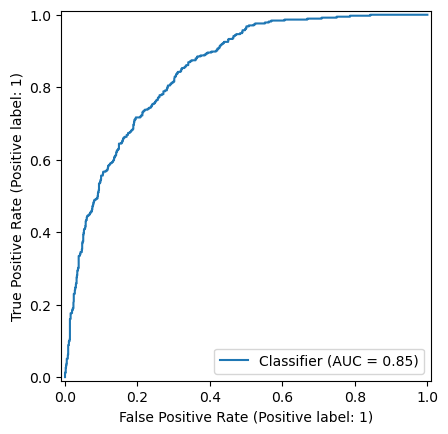

In [169]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob)

In [170]:
import pandas as pd

pd.Series(y_pred).value_counts()

0    1078
1     331
Name: count, dtype: int64

In [171]:
pd.Series(y_test).value_counts()

Churn Value
0    1035
1     374
Name: count, dtype: int64

In [172]:
manual_pred_05 = (y_prob >= 0.5).astype(int)

(manual_pred_05 == y_pred).all()

True

## Threshold Tuning

Because churn is an imbalanced target, the decision threshold is compared at multiple cutoffs to show the trade-off between precision and recall for the positive class.

In [173]:
y_pred_04 = (y_prob >= 0.4).astype(int)
pd.Series(y_pred_04).value_counts()

0    974
1    435
Name: count, dtype: int64

In [174]:
print(classification_report(y_test, y_pred_04))

              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1035
           1       0.58      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.78      0.79      1409



In [175]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [176]:
confusion_matrix(y_test, y_pred_04)

array([[852, 183],
       [122, 252]])

In [177]:
confusion_matrix(y_test, y_pred)

array([[917, 118],
       [161, 213]])

In [178]:
y_pred_03 = (y_prob >= 0.3).astype(int)
print(classification_report(y_test, y_pred_03))

              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



In [179]:
threshold_results = pd.DataFrame({
    "threshold": [0.5, 0.4, 0.3],
    "predicted_churns": [
        (y_prob >= 0.5).sum(),
        (y_prob >= 0.4).sum(),
        (y_prob >= 0.3).sum()
    ]
})

threshold_results

,threshold,predicted_churns
0,0.5,331
1,0.4,435
2,0.3,524


In [180]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results["precision_class_1"] = [
    precision_score(y_test, (y_prob >= 0.5).astype(int)),
    precision_score(y_test, (y_prob >= 0.4).astype(int)),
    precision_score(y_test, (y_prob >= 0.3).astype(int))
]

threshold_results["recall_class_1"] = [
    recall_score(y_test, (y_prob >= 0.5).astype(int)),
    recall_score(y_test, (y_prob >= 0.4).astype(int)),
    recall_score(y_test, (y_prob >= 0.3).astype(int))
]

threshold_results["f1_class_1"] = [
    f1_score(y_test, (y_prob >= 0.5).astype(int)),
    f1_score(y_test, (y_prob >= 0.4).astype(int)),
    f1_score(y_test, (y_prob >= 0.3).astype(int))
]

threshold_results

,threshold,predicted_churns,precision_class_1,recall_class_1,f1_class_1
0,0.5,331,0.643505,0.569519,0.604255
1,0.4,435,0.579310,0.673797,0.622991
2,0.3,524,0.532443,0.745989,0.621381


### Threshold Comparison Summary

- At threshold 0.5, the model is more conservative:
  fewer customers are flagged as churn, precision is higher, but recall is lower.
- At threshold 0.3, the model is more aggressive:
  more customers are flagged as churn, recall is higher, but precision is lower.
- At threshold 0.4, the model gives the best balance among the tested thresholds for class-1 performance in this baseline experiment.

For now, 0.4 looks like a reasonable candidate threshold if the business wants to catch more churners without becoming too aggressive.

In [181]:
final_threshold = 0.4
final_pred = (y_prob >= final_threshold).astype(int)

In [182]:
print(classification_report(y_test, final_pred))
confusion_matrix(y_test, final_pred)

              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1035
           1       0.58      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.78      0.79      1409



array([[852, 183],
       [122, 252]])

## Coefficient Inspection

Since the baseline model is linear, the learned coefficients provide a quick directional view of which encoded features push predictions toward or away from churn.

In [183]:
import numpy as np

In [184]:
feature_names = clf.named_steps["preprocessor"].get_feature_names_out()

coefficients = clf.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values(by="coefficient", ascending=False)

coef_df.head(10), coef_df.tail(10)

(                                 feature  coefficient
 6                     cat__Dependents_No     0.645479
 34          cat__Contract_Month-to-month     0.563585
 14     cat__Internet Service_Fiber optic     0.550165
 45                    num__Total Charges     0.521700
 41  cat__Payment Method_Electronic check     0.188563
 30                 cat__Streaming TV_Yes     0.168955
 33             cat__Streaming Movies_Yes     0.155942
 16               cat__Online Security_No     0.132466
 25                  cat__Tech Support_No     0.114846
 12               cat__Multiple Lines_Yes     0.081648,
                                        feature  coefficient
 26       cat__Tech Support_No internet service    -0.285275
 23  cat__Device Protection_No internet service    -0.285275
 10                      cat__Multiple Lines_No    -0.299459
 4                              cat__Partner_No    -0.317788
 37                   cat__Paperless Billing_No    -0.350410
 44                        n

Baseline logistic regression interpretation:

Main churn-associated signals in this baseline:
- Month-to-month contract is strongly associated with higher churn.
- Fiber optic internet is associated with higher churn in this dataset.
- Customers without dependents are more churn-prone.
- Electronic check payment method is associated with higher churn.
- Customers without online security or tech support are more churn-prone.

Main retention-associated signals in this baseline:
- Longer tenure is strongly associated with lower churn.
- Two-year contracts are strongly associated with lower churn.
- Customers with dependents are less likely to churn.

Important note:
These coefficients show association in the baseline logistic regression model, not guaranteed causal effects.

In [185]:
top_churn_drivers = coef_df.head(10).copy()
top_retention_drivers = coef_df.tail(10).sort_values("coefficient").copy()

top_churn_drivers, top_retention_drivers

(                                 feature  coefficient
 6                     cat__Dependents_No     0.645479
 34          cat__Contract_Month-to-month     0.563585
 14     cat__Internet Service_Fiber optic     0.550165
 45                    num__Total Charges     0.521700
 41  cat__Payment Method_Electronic check     0.188563
 30                 cat__Streaming TV_Yes     0.168955
 33             cat__Streaming Movies_Yes     0.155942
 16               cat__Online Security_No     0.132466
 25                  cat__Tech Support_No     0.114846
 12               cat__Multiple Lines_Yes     0.081648,
                                        feature  coefficient
 43                          num__Tenure Months    -1.270244
 7                          cat__Dependents_Yes    -0.989424
 36                      cat__Contract_Two year    -0.734672
 13                   cat__Internet Service_DSL    -0.608835
 44                        num__Monthly Charges    -0.497754
 37                   cat__P

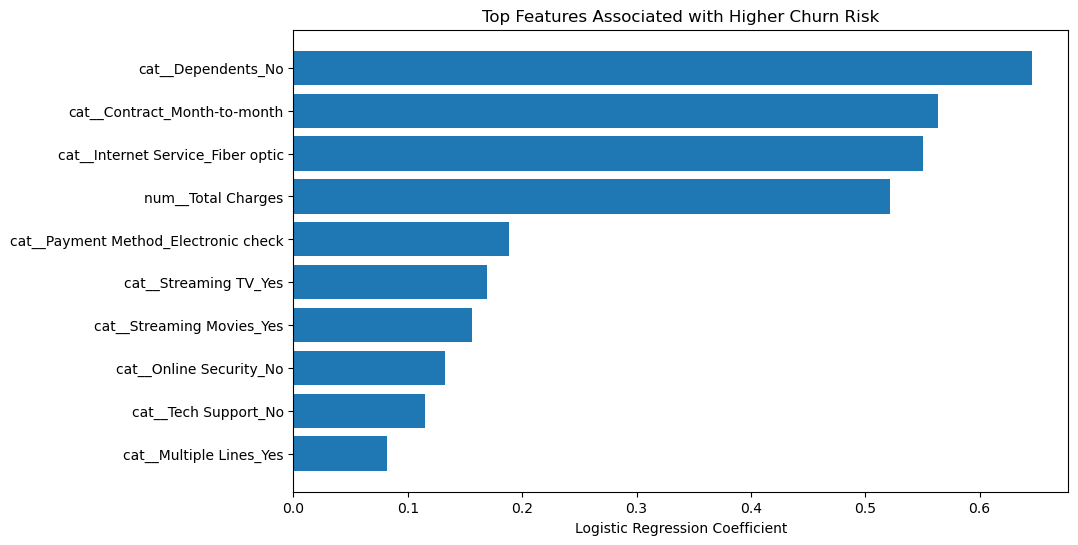

In [186]:
import matplotlib.pyplot as plt

top_churn_drivers = coef_df.head(10).copy()
top_retention_drivers = coef_df.tail(10).sort_values("coefficient").copy()

plt.figure(figsize=(10, 6))
plt.barh(top_churn_drivers["feature"], top_churn_drivers["coefficient"])
plt.xlabel("Logistic Regression Coefficient")
plt.title("Top Features Associated with Higher Churn Risk")
plt.gca().invert_yaxis()
plt.show()

In [187]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_reg_tuned = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

param_grid = [
    {
        "classifier__solver": ["liblinear"],
        "classifier__penalty": ["l1", "l2"],
        "classifier__C": [0.01, 0.1, 1, 10],
        "classifier__class_weight": [None, "balanced"]
    },
    {
        "classifier__solver": ["lbfgs"],
        "classifier__penalty": ["l2"],
        "classifier__C": [0.01, 0.1, 1, 10],
        "classifier__class_weight": [None, "balanced"]
    }
]

grid_search = GridSearchCV(
    estimator=log_reg_tuned,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best CV ROC AUC:", grid_search.best_score_)
print("Best parameters:")
print(grid_search.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV ROC AUC: 0.8591609244655192
Best parameters:
{'classifier__C': 10, 'classifier__class_weight': None, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}


In [188]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

best_log_reg = grid_search.best_estimator_

tuned_prob = best_log_reg.predict_proba(X_test)[:, 1]
tuned_pred = best_log_reg.predict(X_test)

tuned_auc = roc_auc_score(y_test, tuned_prob) #here you have to give prob not pred, because roc_auc_score needs the
#predicted probabilities to calculate the area under the curve, which is a measure of how well the model can distinguish between
#  the classes. Using predicted class labels instead of probabilities would not provide the necessary 
# information for this calculation and would lead to an incorrect evaluation of the model's performance.

print("Tuned Logistic Regression Test ROC AUC:", tuned_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tuned_pred))

print("\nClassification Report:")
print(classification_report(y_test, tuned_pred))

Tuned Logistic Regression Test ROC AUC: 0.8481050918391071

Confusion Matrix:
[[911 124]
 [162 212]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1035
           1       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [189]:
model_results = pd.DataFrame([
    {
        "model": "Tuned Logistic Regression",
        "roc_auc": tuned_auc,
        "accuracy": 0.80,
        "churn_precision": 0.63,
        "churn_recall": 0.57,
        "churn_f1": 0.60
    }
])

model_results

,model,roc_auc,accuracy,churn_precision,churn_recall,churn_f1
0,Tuned Logistic Regression,0.848105,0.8,0.63,0.57,0.6


In [190]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_pred = rf_model.predict(X_test)

rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Test ROC AUC:", rf_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Test ROC AUC: 0.8319589759487458

Confusion Matrix:
[[920 115]
 [185 189]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [191]:
new_result = pd.DataFrame([
    {
        "model": "Random Forest Baseline",
        "roc_auc": rf_auc,
        "accuracy": 0.79,
        "churn_precision": 0.62,
        "churn_recall": 0.51,
        "churn_f1": 0.56
    }
])

model_results = pd.concat([model_results, new_result], ignore_index=True)

model_results

,model,roc_auc,accuracy,churn_precision,churn_recall,churn_f1
0,Tuned Logistic Regression,0.848105,0.80,0.63,0.57,0.60
1,Random Forest Baseline,0.831959,0.79,0.62,0.51,0.56


In [192]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

gb_prob = gb_model.predict_proba(X_test)[:, 1]
gb_pred = gb_model.predict(X_test)

gb_auc = roc_auc_score(y_test, gb_prob)

print("Gradient Boosting Test ROC AUC:", gb_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_pred))

print("\nClassification Report:")
print(classification_report(y_test, gb_pred))

Gradient Boosting Test ROC AUC: 0.8534126430545869

Confusion Matrix:
[[932 103]
 [173 201]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



In [193]:
new_result = pd.DataFrame([
    {
        "model": "Gradient Boosting Baseline",
        "roc_auc": gb_auc,
        "accuracy": 0.80,
        "churn_precision": 0.66,
        "churn_recall": 0.54,
        "churn_f1": 0.59
    }
])

model_results = pd.concat([model_results, new_result], ignore_index=True)

model_results

,model,roc_auc,accuracy,churn_precision,churn_recall,churn_f1
0,Tuned Logistic Regression,0.848105,0.80,0.63,0.57,0.60
1,Random Forest Baseline,0.831959,0.79,0.62,0.51,0.56
2,Gradient Boosting Baseline,0.853413,0.80,0.66,0.54,0.59


In [194]:
import xgboost as xgb

print(xgb.__version__)

3.0.4


In [195]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict(X_test)

xgb_auc = roc_auc_score(y_test, xgb_prob)

print("XGBoost Test ROC AUC:", xgb_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

XGBoost Test ROC AUC: 0.8544227440646879

Confusion Matrix:
[[927 108]
 [164 210]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [196]:
new_result = pd.DataFrame([
    {
        "model": "XGBoost Baseline",
        "roc_auc": xgb_auc,
        "accuracy": 0.81,
        "churn_precision": 0.66,
        "churn_recall": 0.56,
        "churn_f1": 0.61
    }
])

model_results = pd.concat([model_results, new_result], ignore_index=True)

model_results

,model,roc_auc,accuracy,churn_precision,churn_recall,churn_f1
0,Tuned Logistic Regression,0.848105,0.80,0.63,0.57,0.60
1,Random Forest Baseline,0.831959,0.79,0.62,0.51,0.56
2,Gradient Boosting Baseline,0.853413,0.80,0.66,0.54,0.59
3,XGBoost Baseline,0.854423,0.81,0.66,0.56,0.61


In [197]:
(xgb_prob >= 0.3).astype(int)

array([0, 1, 0, ..., 0, 0, 0])

In [198]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50]:
    xgb_pred_threshold = (xgb_prob >= threshold).astype(int)
    
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, xgb_pred_threshold),
        "recall": recall_score(y_test, xgb_pred_threshold),
        "f1": f1_score(y_test, xgb_pred_threshold)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,threshold,precision,recall,f1
0,0.30,0.543396,0.770053,0.637168
1,0.35,0.564315,0.727273,0.635514
2,0.40,0.585308,0.660428,0.620603
3,0.45,0.617021,0.620321,0.618667
4,0.50,0.660377,0.561497,0.606936


In [199]:
xgb_prob

array([0.02568453, 0.84985644, 0.1666415 , ..., 0.11198966, 0.02943489,
       0.00145809], dtype=float32)

In [201]:
(xgb_prob >= 0.3).astype(int)

array([0, 1, 0, ..., 0, 0, 0])

In [202]:
selected_threshold = 0.30

xgb_pred_selected = (xgb_prob >= selected_threshold).astype(int)

print("Selected Threshold:", selected_threshold)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred_selected))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred_selected))

Selected Threshold: 0.3

Confusion Matrix:
[[793 242]
 [ 86 288]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.54      0.77      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409



In [203]:
new_result = pd.DataFrame([
    {
        "model": "XGBoost Threshold 0.30",
        "roc_auc": xgb_auc,
        "accuracy": 0.77,
        "churn_precision": 0.54,
        "churn_recall": 0.77,
        "churn_f1": 0.64
    }
])

model_results = pd.concat([model_results, new_result], ignore_index=True)

model_results

,model,roc_auc,accuracy,churn_precision,churn_recall,churn_f1
0,Tuned Logistic Regression,0.848105,0.80,0.63,0.57,0.60
1,Random Forest Baseline,0.831959,0.79,0.62,0.51,0.56
2,Gradient Boosting Baseline,0.853413,0.80,0.66,0.54,0.59
3,XGBoost Baseline,0.854423,0.81,0.66,0.56,0.61
4,XGBoost Threshold 0.30,0.854423,0.77,0.54,0.77,0.64


## Threshold Selection: XGBoost

The XGBoost baseline model achieved the strongest ROC AUC among the models tested so far. However, using the default classification threshold of 0.50 only captured 56% of actual churners.

Because this is a churn prediction problem, recall is especially important. Missing a customer who is likely to churn may mean losing future revenue. Therefore, we tested lower probability thresholds to make the model more aggressive in flagging at-risk customers.

At a threshold of 0.30, the model achieved:

- Churn precision: 0.54
- Churn recall: 0.77
- Churn F1-score: 0.64

This means the model correctly identifies approximately 77% of actual churners. The tradeoff is that more non-churn customers are incorrectly flagged as churn risks. In a real business setting, this tradeoff may be acceptable if the cost of a retention offer is lower than the expected revenue lost from churn.

For this stage of the project, XGBoost with a 0.30 threshold is selected as the current business-friendly churn model.

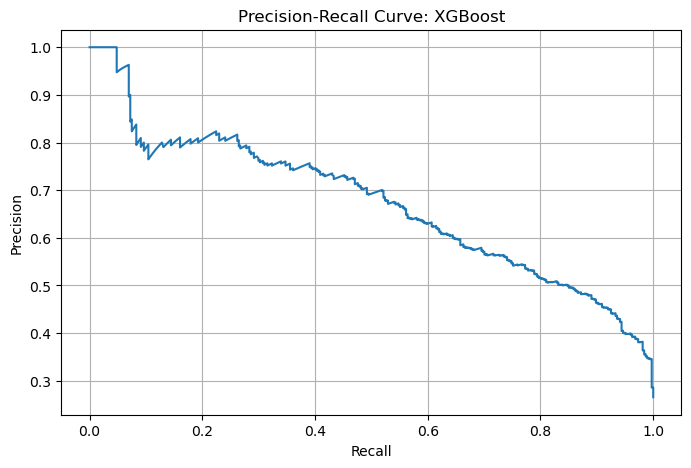

In [204]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, xgb_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: XGBoost")
plt.grid(True)
plt.show()

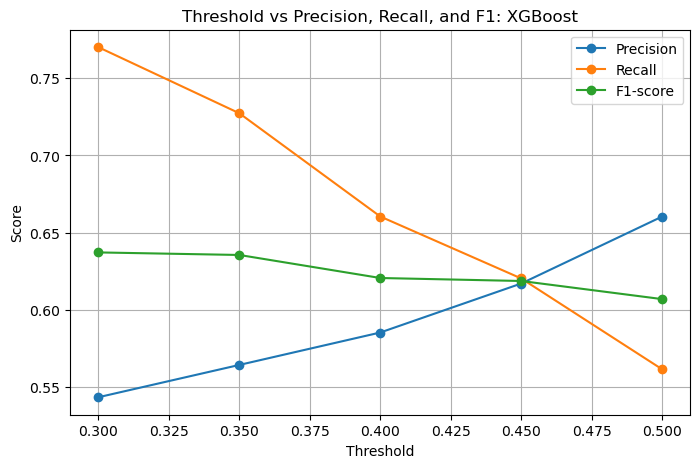

In [205]:
plt.figure(figsize=(8, 5))

plt.plot(threshold_results_df["threshold"], threshold_results_df["precision"], marker="o", label="Precision")
plt.plot(threshold_results_df["threshold"], threshold_results_df["recall"], marker="o", label="Recall")
plt.plot(threshold_results_df["threshold"], threshold_results_df["f1"], marker="o", label="F1-score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision, Recall, and F1: XGBoost")
plt.legend()
plt.grid(True)
plt.show()

## Threshold Tradeoff Interpretation

The threshold comparison chart shows the tradeoff between precision and recall for the XGBoost model.

As the threshold increases from 0.30 to 0.50, precision improves because the model becomes more selective about who it labels as churn. However, recall decreases because the model misses more actual churners.

For this churn prediction use case, threshold 0.30 provides the best business-friendly balance. It gives the highest F1-score among the tested thresholds and captures approximately 77% of actual churners.

This threshold is more aggressive than the default 0.50 threshold, but that is reasonable for a retention use case where missing a likely churner may be more expensive than sending a retention offer to a customer who would not have churned.

In [206]:
feature_names = xgb_model.named_steps["preprocessor"].get_feature_names_out()

xgb_importances = xgb_model.named_steps["classifier"].feature_importances_

xgb_feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_importances
})

xgb_feature_importance = xgb_feature_importance.sort_values(
    "importance",
    ascending=False
)

xgb_feature_importance.head(20)

,feature,importance
34,cat__Contract_Month-to-month,0.257401
16,cat__Online Security_No,0.107964
14,cat__Internet Service_Fiber optic,0.089629
25,cat__Tech Support_No,0.062362
6,cat__Dependents_No,0.040697
7,cat__Dependents_Yes,0.033291
41,cat__Payment Method_Electronic check,0.032193
36,cat__Contract_Two year,0.030202
15,cat__Internet Service_No,0.028974
33,cat__Streaming Movies_Yes,0.022878


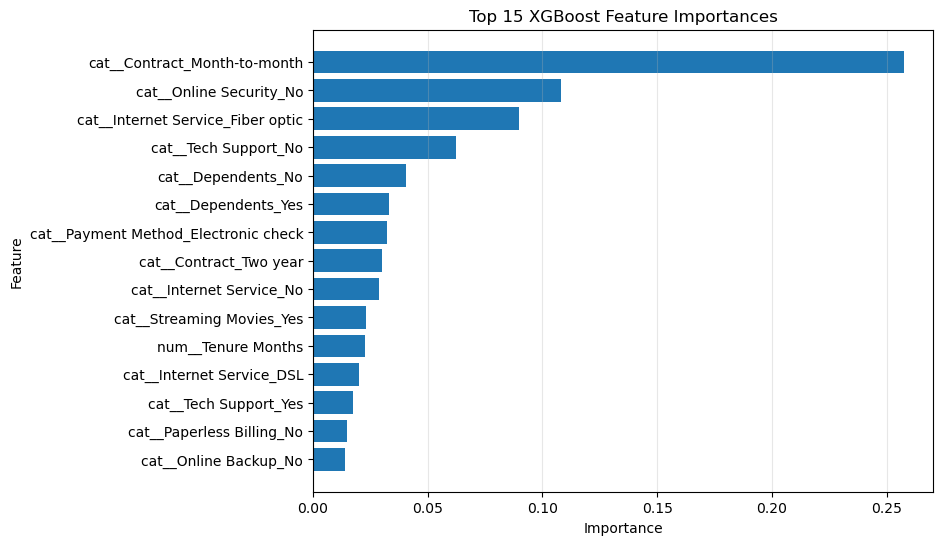

In [207]:
top_features = xgb_feature_importance.head(15).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")
plt.grid(axis="x", alpha=0.3)
plt.show()

## XGBoost Feature Importance Interpretation

The XGBoost feature importance results show that the strongest churn-related signal is `Contract_Month-to-month`. This suggests that customers on month-to-month contracts are much more likely to churn than customers on longer-term contracts.

Other important churn-related features include lack of online security, fiber optic internet service, lack of tech support, electronic check payment method, and tenure months.

From a business perspective, these features make sense:

- Month-to-month customers have less commitment and can cancel more easily.
- Customers without online security or tech support may experience lower perceived service value.
- Fiber optic customers may have higher monthly bills, which can increase price sensitivity.
- Electronic check payment customers may represent a segment with higher churn behavior.
- Tenure matters because newer customers are often less stable and less loyal.

These feature importance results support the retention strategy of focusing on customers with short tenure, month-to-month contracts, limited support services, and high-risk billing/payment patterns.

In [208]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    xgb_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
})

perm_importance_df = perm_importance_df.sort_values(
    "importance_mean",
    ascending=False
)

perm_importance_df.head(15)

,feature,importance_mean,importance_std
14,Contract,0.056744,0.004835
4,Tenure Months,0.054035,0.003218
3,Dependents,0.038291,0.005500
7,Internet Service,0.007063,0.003347
8,Online Security,0.005513,0.001141
17,Monthly Charges,0.004938,0.002390
18,Total Charges,0.004272,0.002481
11,Tech Support,0.003524,0.001520
15,Paperless Billing,0.003171,0.001485
2,Partner,0.003148,0.001068


## Permutation Importance Interpretation

Permutation importance was used to validate which original input columns most affected model performance.

Unlike XGBoost's built-in feature importance, which operates on transformed one-hot encoded features, permutation importance evaluates the original columns by randomly shuffling each column and measuring how much ROC AUC decreases.

The strongest original churn drivers were Contract, Tenure Months, Dependents, Internet Service, Online Security, Monthly Charges, Total Charges, and Tech Support.

This supports the earlier feature importance results. Contract type and tenure are especially important, which means churn risk is strongly tied to customer commitment and customer lifecycle stage. Service-related variables such as online security and tech support also matter, suggesting that customers with weaker service bundles may be more likely to churn.

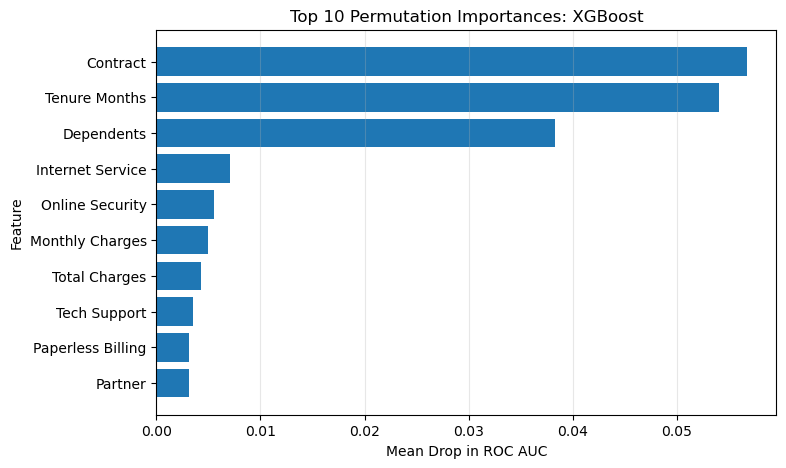

In [209]:
top_perm_features = perm_importance_df.head(10).sort_values(
    "importance_mean",
    ascending=True
)

plt.figure(figsize=(8, 5))
plt.barh(top_perm_features["feature"], top_perm_features["importance_mean"])
plt.xlabel("Mean Drop in ROC AUC")
plt.ylabel("Feature")
plt.title("Top 10 Permutation Importances: XGBoost")
plt.grid(axis="x", alpha=0.3)
plt.show()

In [210]:
final_model_summary = pd.DataFrame([
    {
        "selected_model": "XGBoost",
        "selected_threshold": 0.30,
        "roc_auc": xgb_auc,
        "accuracy": 0.77,
        "churn_precision": 0.54,
        "churn_recall": 0.77,
        "churn_f1": 0.64,
        "business_goal": "Prioritize recall to identify more at-risk churn customers"
    }
])

final_model_summary

,selected_model,selected_threshold,roc_auc,accuracy,churn_precision,churn_recall,churn_f1,business_goal
0,XGBoost,0.3,0.854423,0.77,0.54,0.77,0.64,Prioritize recall to identify more at-risk chu...


In [211]:
X_test[["Monthly Charges"]].head()

,Monthly Charges
2196,114.05
3549,100.15
3515,78.35
5162,78.20
4642,82.65


In [212]:
business_df = X_test.copy()

business_df["actual_churn"] = y_test.values
business_df["churn_probability"] = xgb_prob
business_df["predicted_churn"] = xgb_pred_selected

business_df["estimated_annual_revenue"] = business_df["Monthly Charges"] * 12

business_df[[
    "Monthly Charges",
    "estimated_annual_revenue",
    "actual_churn",
    "churn_probability",
    "predicted_churn"
]].head()

,Monthly Charges,estimated_annual_revenue,actual_churn,churn_probability,predicted_churn
2196,114.05,1368.6,0,0.025685,0
3549,100.15,1201.8,0,0.849856,1
3515,78.35,940.2,0,0.166642,0
5162,78.20,938.4,0,0.383176,1
4642,82.65,991.8,0,0.009715,0


In [213]:
flagged_customers = business_df[business_df["predicted_churn"] == 1]

num_flagged = len(flagged_customers)

flagged_annual_revenue = flagged_customers["estimated_annual_revenue"].sum()

actual_churners_flagged = flagged_customers[flagged_customers["actual_churn"] == 1]

num_actual_churners_flagged = len(actual_churners_flagged)

actual_churn_revenue_captured = actual_churners_flagged["estimated_annual_revenue"].sum()

print("Number of customers flagged for retention:", num_flagged)
print("Estimated annual revenue among all flagged customers:", flagged_annual_revenue)
print("Actual churners correctly flagged:", num_actual_churners_flagged)
print("Estimated annual revenue from correctly flagged churners:", actual_churn_revenue_captured)

Number of customers flagged for retention: 530
Estimated annual revenue among all flagged customers: 475244.39999999997
Actual churners correctly flagged: 288
Estimated annual revenue from correctly flagged churners: 258240.6


In [214]:
retention_offer_cost = 50
retention_success_rate = 0.25

total_retention_cost = num_flagged * retention_offer_cost

estimated_revenue_saved = actual_churn_revenue_captured * retention_success_rate

estimated_net_value = estimated_revenue_saved - total_retention_cost

roi = estimated_net_value / total_retention_cost

print("Total retention campaign cost:", total_retention_cost)
print("Estimated revenue saved:", estimated_revenue_saved)
print("Estimated net value:", estimated_net_value)
print("Estimated ROI:", roi)

Total retention campaign cost: 26500
Estimated revenue saved: 64560.15
Estimated net value: 38060.15
Estimated ROI: 1.4362320754716982


In [215]:
roi_summary = pd.DataFrame([
    {
        "selected_model": "XGBoost",
        "threshold": selected_threshold,
        "customers_flagged": num_flagged,
        "actual_churners_caught": num_actual_churners_flagged,
        "annual_revenue_at_risk_captured": actual_churn_revenue_captured,
        "retention_offer_cost_per_customer": retention_offer_cost,
        "retention_success_rate": retention_success_rate,
        "total_retention_cost": total_retention_cost,
        "estimated_revenue_saved": estimated_revenue_saved,
        "estimated_net_value": estimated_net_value,
        "estimated_roi": roi
    }
])

roi_summary

,selected_model,threshold,customers_flagged,actual_churners_caught,annual_revenue_at_risk_captured,retention_offer_cost_per_customer,retention_success_rate,total_retention_cost,estimated_revenue_saved,estimated_net_value,estimated_roi
0,XGBoost,0.3,530,288,258240.6,50,0.25,26500,64560.15,38060.15,1.436232


## Current Project Status and Next Steps

This notebook completes the first end-to-end churn modeling prototype. The project now includes model training, model comparison, threshold tuning, feature importance, permutation importance, and a basic ROI simulation.

The current selected model is XGBoost with a 0.30 decision threshold. This threshold was chosen because the business goal is to prioritize churn recall. At this threshold, the model captures approximately 77% of actual churners while maintaining a churn precision of approximately 54%.

The business simulation estimates that targeting 530 flagged customers with a $50 retention offer could capture 288 actual churners. These correctly flagged churners represent approximately $258K in annual revenue at risk. Assuming a 25% retention success rate, the campaign could save approximately $64.6K in revenue, with an estimated net value of approximately $38.1K and ROI of 1.44.

Next steps for making this project production-style:
1. Save the trained preprocessing + XGBoost pipeline as a reusable model artifact.
2. Create a batch inference script that scores new customer records.
3. Generate a scored customer output table with churn probability, risk segment, and estimated revenue at risk.
4. Build a Streamlit dashboard for model results and ROI simulation.
5. Later, deploy the scoring workflow using cloud storage and scheduled batch jobs.

In [216]:
import joblib

joblib.dump(xgb_model, "./xgb_churn_pipeline.joblib")

['./xgb_churn_pipeline.joblib']

In [217]:
pwd

'/Users/chanamalluvinay/Documents/telco-churn-prediction/notebooks'

In [218]:
loaded_model = joblib.load("/Users/chanamalluvinay/Documents/telco-churn-prediction/models/xgb_churn_pipeline.joblib")

loaded_prob = loaded_model.predict_proba(X_test)[:, 1]

loaded_pred = (loaded_prob >= selected_threshold).astype(int)

print("Loaded model test ROC AUC:", roc_auc_score(y_test, loaded_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, loaded_pred))
print("\nClassification Report:")
print(classification_report(y_test, loaded_pred))

Loaded model test ROC AUC: 0.8534914361001318

Confusion Matrix:
[[793 242]
 [ 88 286]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.54      0.76      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [219]:
scored_customers = X_test.copy()

scored_customers["churn_probability"] = loaded_prob
scored_customers["predicted_churn"] = loaded_pred
scored_customers["estimated_annual_revenue"] = scored_customers["Monthly Charges"] * 12

scored_customers["risk_segment"] = pd.cut(
    scored_customers["churn_probability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

scored_customers[[
    "churn_probability",
    "predicted_churn",
    "risk_segment",
    "Monthly Charges",
    "estimated_annual_revenue"
]].head()

,churn_probability,predicted_churn,risk_segment,Monthly Charges,estimated_annual_revenue
2196,0.020154,0,Low Risk,114.05,1368.6
3549,0.846991,1,High Risk,100.15,1201.8
3515,0.145096,0,Low Risk,78.35,940.2
5162,0.412379,1,Medium Risk,78.20,938.4
4642,0.011354,0,Low Risk,82.65,991.8


In [220]:
scored_customers.to_csv("/Users/chanamalluvinay/Documents/telco-churn-prediction/data/scored_churn_customers.csv", index=False)

In [221]:
risk_segment_summary = scored_customers.groupby("risk_segment").agg(
    customer_count=("risk_segment", "count"),
    avg_churn_probability=("churn_probability", "mean"),
    total_estimated_annual_revenue=("estimated_annual_revenue", "sum"),
    avg_monthly_charges=("Monthly Charges", "mean")
).reset_index()

risk_segment_summary

/var/folders/hm/4ll25pyj60g_145pzvzm_jbh0000gn/T/ipykernel_24275/3485886812.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_segment_summary = scored_customers.groupby("risk_segment").agg(


,risk_segment,customer_count,avg_churn_probability,total_estimated_annual_revenue,avg_monthly_charges
0,Low Risk,881,0.083177,610485.0,57.745460
1,Medium Risk,323,0.454142,275616.0,71.108359
2,High Risk,205,0.748291,197513.4,80.290000


In [222]:
risk_segment_summary.to_csv("../data/risk_segment_summary.csv", index=False)

## Batch Scoring Output

The trained XGBoost pipeline was saved as a reusable model artifact and then loaded back successfully to verify that it produces the same predictions after serialization.

Using the loaded model, the test customer records were scored and exported into a batch scoring output file. This scored customer table includes churn probability, predicted churn label, risk segment, monthly charges, and estimated annual revenue.

A separate risk segment summary table was also created. This table groups customers into Low Risk, Medium Risk, and High Risk segments and summarizes customer count, average churn probability, total estimated annual revenue, and average monthly charges.

These files represent the first production-style outputs of the project:

- `models/xgb_churn_pipeline.joblib`
- `data/scored_churn_customers.csv`
- `data/risk_segment_summary.csv`

In a real churn system, this batch scoring output could be generated on a scheduled basis and consumed by a dashboard or retention campaign workflow.

In [223]:
import shap

print(shap.__version__)

0.47.2


In [224]:
# Get the preprocessing step and trained XGBoost model from the pipeline
preprocessor = xgb_model.named_steps["preprocessor"]
xgb_classifier = xgb_model.named_steps["classifier"]

# Transform the test features the same way the pipeline does internally
X_test_transformed = preprocessor.transform(X_test)

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Convert transformed test data into a DataFrame for easier SHAP interpretation
X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

# Create SHAP explainer for the trained XGBoost model
explainer = shap.TreeExplainer(xgb_classifier)

# Calculate SHAP values for the transformed test data
shap_values = explainer.shap_values(X_test_transformed_df)

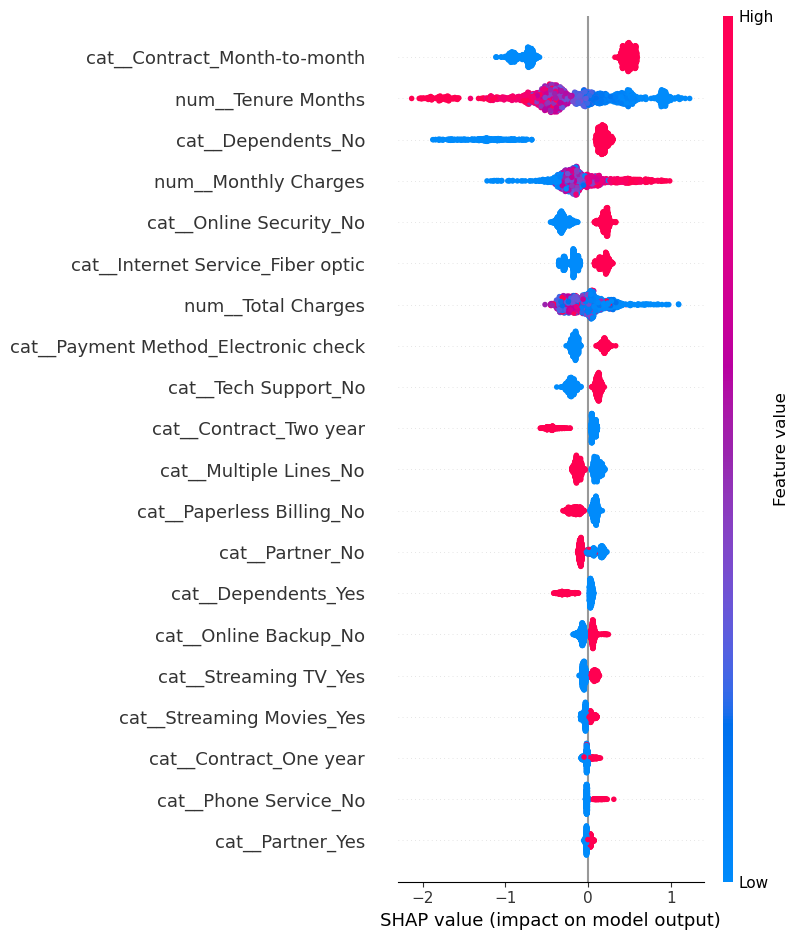

In [225]:
shap.summary_plot(
    shap_values,
    X_test_transformed_df,
    max_display=20
)

## SHAP Global Explanation

The SHAP summary plot confirms the main churn drivers identified earlier through XGBoost feature importance and permutation importance.

The strongest driver is month-to-month contract status. Customers on month-to-month contracts tend to receive higher churn predictions, while longer-term contracts reduce churn risk.

Tenure is also highly influential. Lower-tenure customers are more likely to be classified as churn risks, while longer-tenure customers are generally more stable.

Higher monthly charges, lack of online security, fiber optic internet service, electronic check payment method, and lack of tech support also increase churn risk.

Overall, SHAP supports the business interpretation that churn risk is concentrated among customers with low commitment, shorter tenure, higher charges, and weaker service/support bundles.

In [227]:
# Pick the customer with the highest predicted churn probability
high_risk_index = xgb_prob.argmax()

# Show this customer's churn probability
print("Customer index:", high_risk_index)
print("Churn probability:", xgb_prob[high_risk_index])

Customer index: 1175
Churn probability: 0.93843


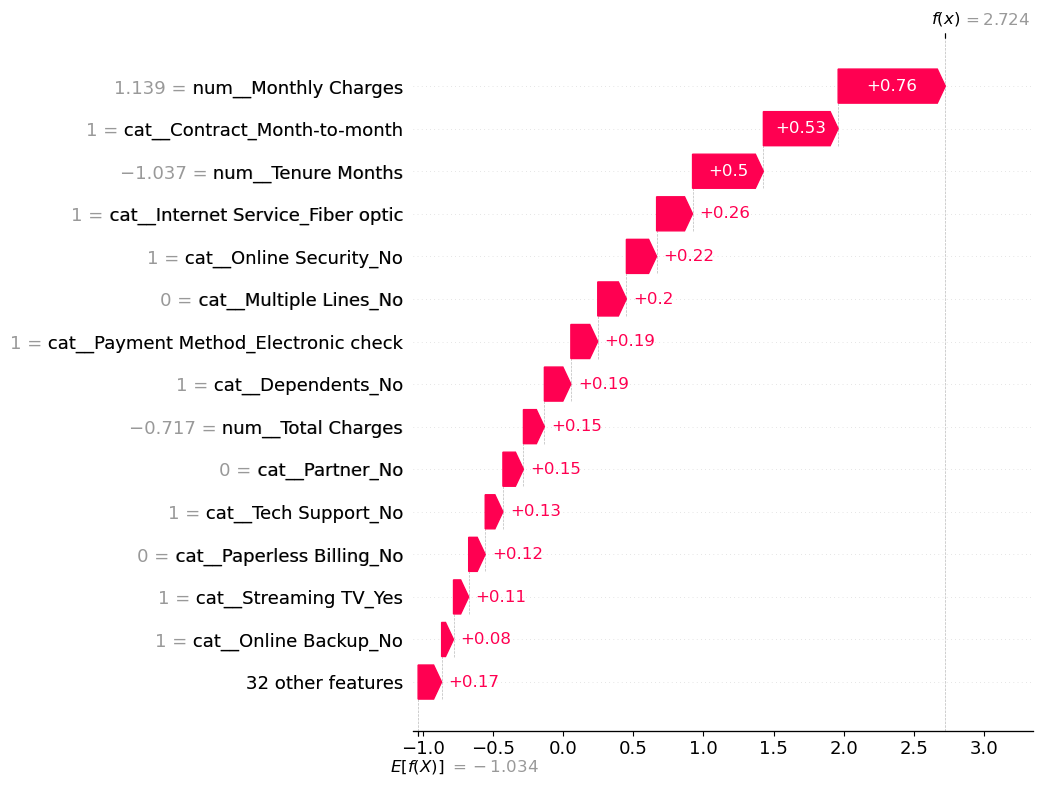

In [228]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[high_risk_index],
        base_values=explainer.expected_value,
        data=X_test_transformed_df.iloc[high_risk_index],
        feature_names=X_test_transformed_df.columns
    ),
    max_display=15
)

## SHAP Local Explanation: High-Risk Customer

The SHAP waterfall plot explains why one individual customer received a high churn prediction.

For this customer, the strongest upward drivers of churn risk were high monthly charges, month-to-month contract status, low tenure, fiber optic internet service, no online security, electronic check payment method, no dependents, and no tech support.

This local explanation is useful because it turns the model prediction into an actionable retention story. Instead of only saying that the customer is high risk, the model can also explain why the customer is high risk.

For example, this customer may be a strong candidate for a retention offer focused on contract conversion, price relief, or bundled support/security services.

In [229]:
shap_importance_df = pd.DataFrame({
    "feature": X_test_transformed_df.columns,
    "mean_abs_shap_value": abs(shap_values).mean(axis=0)
})

shap_importance_df = shap_importance_df.sort_values(
    "mean_abs_shap_value",
    ascending=False
)

shap_importance_df.head(20)

,feature,mean_abs_shap_value
34,cat__Contract_Month-to-month,0.620068
43,num__Tenure Months,0.532801
6,cat__Dependents_No,0.426002
44,num__Monthly Charges,0.261196
16,cat__Online Security_No,0.254055
14,cat__Internet Service_Fiber optic,0.202847
45,num__Total Charges,0.181431
41,cat__Payment Method_Electronic check,0.174711
25,cat__Tech Support_No,0.161871
36,cat__Contract_Two year,0.155936


In [230]:
shap_importance_df.to_csv("../data/processed/shap_feature_importance.csv", index=False)

In [231]:
# Create a sample inference dataset from the original Telco dataframe

columns_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Value",
    "Churn Score",
    "CLTV",
    "Churn Reason",
]

sample_inference_df = df.drop(columns=columns_to_drop, errors="ignore").copy()

sample_inference_df["Total Charges"] = pd.to_numeric(
    sample_inference_df["Total Charges"],
    errors="coerce"
)

sample_inference_df = sample_inference_df.sample(
    n=100,
    random_state=42
)

sample_inference_df.to_csv(
    "../data/processed/sample_inference_customers.csv",
    index=False
)

sample_inference_df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges
185,Female,No,No,No,15,Yes,No,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),85.9,1269.55
2715,Male,No,Yes,No,18,Yes,Yes,DSL,No,Yes,No,No,No,No,Month-to-month,No,Credit card (automatic),56.8,1074.65
3825,Female,No,No,No,2,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.0,40.90
1807,Male,Yes,Yes,No,6,Yes,No,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,Yes,Electronic check,84.2,519.15
132,Male,No,No,No,40,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,No,Bank transfer (automatic),104.8,4131.95


In [234]:
pwd

'/Users/chanamalluvinay/Documents/telco-churn-prediction/notebooks'

In [236]:
import pandas as pd

sample = pd.read_csv("/Users/chanamalluvinay/Documents/telco-churn-prediction/data/processed/sample_inference_customers.csv")
synthetic = pd.read_csv("/Users/chanamalluvinay/Documents/telco-churn-prediction/data/processed/synthetic_new_customers.csv")

print("Sample columns:")
print(sample.columns.tolist())

print("\nSynthetic columns:")
print(synthetic.columns.tolist())

print("\nColumns match:", sample.columns.tolist() == synthetic.columns.tolist())

print("\nSample shape:", sample.shape)
print("Synthetic shape:", synthetic.shape)

Sample columns:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges']

Synthetic columns:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges']

Columns match: True

Sample shape: (100, 19)
Synthetic shape: (1000, 19)
